# Credit Risk Scoring & Expected Loss Analysis
## Notebook 2: Exploratory Data Analysis

This notebook loads the cleaned dataset and explores the statistical properties most relevant to credit risk modelling: class imbalance, default rates by repayment behaviour, and credit limit distributions.

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

PROCESSED_PATH = '../data/processed/cleaned_credit_card_data.csv'
df = pd.read_csv(PROCESSED_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded: 30,000 rows × 24 columns


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT_NEXT_MONTH
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 2. Class Distribution

Understanding class imbalance is the first step before choosing a modelling strategy.

=== Class Distribution ===
Non-Default (0): 23,364  (77.88%)
Default     (1):  6,636  (22.12%)
Total           : 30,000
Imbalance ratio : 3.5 : 1  (non-default : default)


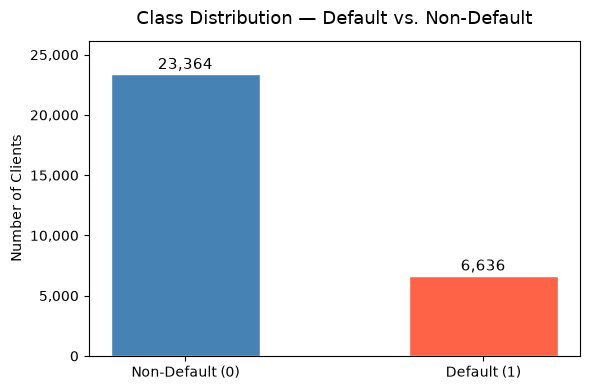

In [2]:
os.makedirs('../figures', exist_ok=True)

default_counts = df['DEFAULT_NEXT_MONTH'].value_counts()
default_rate   = df['DEFAULT_NEXT_MONTH'].mean() * 100

print('=== Class Distribution ===')
print(f"Non-Default (0): {default_counts[0]:>6,}  ({100 - default_rate:.2f}%)")
print(f"Default     (1): {default_counts[1]:>6,}  ({default_rate:.2f}%)")
print(f"Total           : {len(df):>6,}")
print(f"Imbalance ratio : {default_counts[0]/default_counts[1]:.1f} : 1  (non-default : default)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Non-Default (0)', 'Default (1)'],
              default_counts.values,
              color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
for bar, count in zip(bars, default_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{count:,}', ha='center', va='bottom', fontsize=11)
ax.set_title('Class Distribution — Default vs. Non-Default', fontsize=13, pad=12)
ax.set_ylabel('Number of Clients')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, max(default_counts.values) * 1.12)
plt.tight_layout()
plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding**: The portfolio has a **22.12% default rate** — roughly 1 in 4.5 clients defaulted. This constitutes a meaningful class imbalance. Under such conditions, a naive model that always predicts "Non-Default" achieves ~78% accuracy while providing zero value. Both models (Logistic Regression and Random Forest) will use `class_weight='balanced'` to address this.

## 3. Default Rate by Repayment Delay (PAY_0)

`PAY_0` records the repayment status in September 2005. Values ≤ 0 indicate timely payment; values ≥ 1 indicate months of delay.

Default Rate by PAY_0 (Repayment Status):
 PAY_0  Customer_Count  Default_Rate_Pct
    -2            2759              13.2
    -1            5686              16.8
     0           14737              12.8
     1            3688              33.9
     2            2667              69.1
     3             322              75.8
     4              76              68.4
     5              26              50.0
     6              11              54.5
     7               9              77.8
     8              19              57.9


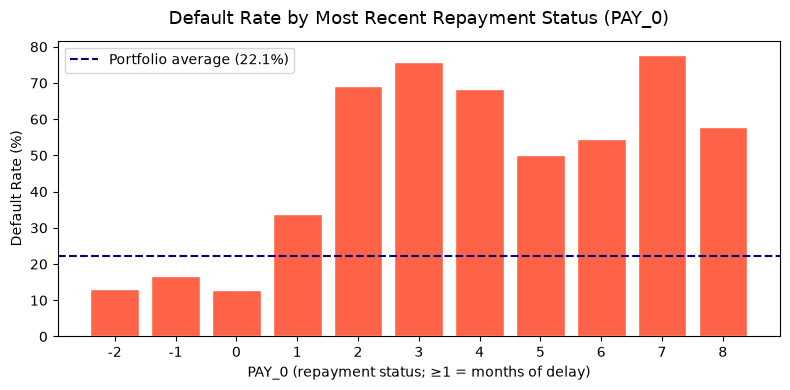

In [3]:
pay0_summary = df.groupby('PAY_0').agg(
    Customer_Count=('DEFAULT_NEXT_MONTH', 'count'),
    Default_Rate_Pct=('DEFAULT_NEXT_MONTH', lambda x: round(x.mean()*100, 1))
).reset_index()
print('Default Rate by PAY_0 (Repayment Status):')
print(pay0_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pay0_summary['PAY_0'].astype(str), pay0_summary['Default_Rate_Pct'],
       color='tomato', edgecolor='white')
ax.axhline(y=default_rate, color='navy', linestyle='--', linewidth=1.5,
           label=f'Portfolio average ({default_rate:.1f}%)')
ax.set_title('Default Rate by Most Recent Repayment Status (PAY_0)', fontsize=13, pad=12)
ax.set_xlabel('PAY_0 (repayment status; ≥1 = months of delay)')
ax.set_ylabel('Default Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/default_by_pay0.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding**: Default probability increases sharply once repayment delays reach **2+ months** (PAY_0 ≥ 2). This is the strongest individual predictor and will dominate feature importance in the trained models.

## 4. Credit Limit Distribution (LIMIT_BAL)

`LIMIT_BAL` is the approved credit card limit. It will be used in Notebook 5 as an **exposure proxy** for the Expected Loss calculation — with explicit acknowledgement that it is not true Exposure at Default (EAD).

LIMIT_BAL — Descriptive Statistics:
count       30,000
mean       167,484
std        129,748
min         10,000
25%         50,000
50%        140,000
75%        240,000
max      1,000,000
Name: LIMIT_BAL, dtype: str

Avg credit limit (Non-Default): NTD 178,100
Avg credit limit (Default):     NTD 130,110


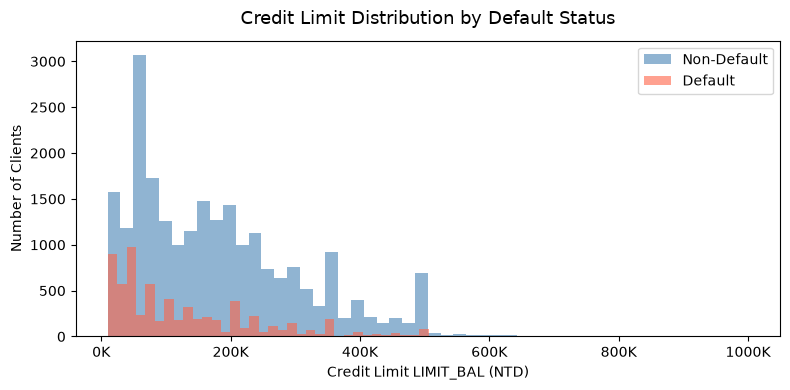

In [4]:
print('LIMIT_BAL — Descriptive Statistics:')
print(df['LIMIT_BAL'].describe().apply(lambda x: f'{x:,.0f}'))
print()
avg_nondefault = df[df['DEFAULT_NEXT_MONTH']==0]['LIMIT_BAL'].mean()
avg_default    = df[df['DEFAULT_NEXT_MONTH']==1]['LIMIT_BAL'].mean()
print(f'Avg credit limit (Non-Default): NTD {avg_nondefault:,.0f}')
print(f'Avg credit limit (Default):     NTD {avg_default:,.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[df['DEFAULT_NEXT_MONTH']==0]['LIMIT_BAL'],
        bins=50, alpha=0.6, color='steelblue', label='Non-Default')
ax.hist(df[df['DEFAULT_NEXT_MONTH']==1]['LIMIT_BAL'],
        bins=50, alpha=0.6, color='tomato',    label='Default')
ax.set_title('Credit Limit Distribution by Default Status', fontsize=13, pad=12)
ax.set_xlabel('Credit Limit LIMIT_BAL (NTD)')
ax.set_ylabel('Number of Clients')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax.legend()
plt.tight_layout()
plt.savefig('../figures/credit_limit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding**: Clients who defaulted had lower average credit limits (NTD ~130K) than non-defaulters (NTD ~178K), consistent with higher-risk clients being granted smaller credit lines. However, credit limit alone is a weak predictor — repayment history carries substantially more signal.

## 5. EDA Summary

| Observation | Detail |
|---|---|
| No missing values | Dataset is complete |
| Class imbalance | 77.88% non-default vs. 22.12% default |
| Strongest predictor | PAY_0 — sharp default spike at 2+ month delay |
| Credit limit | Defaulters have lower average limits; weak standalone predictor |
| Imbalance strategy | Both models use `class_weight='balanced'` |